# Notebook 15 — Final Comparison
Loads all summary JSONs from Drive and generates full results tables and figures.

## 1. Imports

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

## 2. Mount Drive

In [24]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/LungSeg_UNetPP")
print(f"Drive dir: {DRIVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive dir: /content/drive/MyDrive/LungSeg_UNetPP


## 3. Load All Summary JSONs

In [33]:
RUN_MAP = {
    "unetpp_efficientnetb4_CXR"            : DRIVE_DIR / "UNetPP_efficientnet-b4_summary.json",
    "unetpp_efficientnetb4_COVIDQU"        : DRIVE_DIR / "unetpp_efficientnetb4_COVIDQU" / "unetpp_efficientnetb4_COVIDQU_summary.json",
    "unetpp_efficientnetb7_CXR"            : DRIVE_DIR / "unetpp_efficientnetb7_CXR_summary.json",
    "unetpp_resnet50_CXR"                  : DRIVE_DIR / "unetpp_resnet50_CXR" / "unetpp_resnet50_CXR_summary.json",
    "unetpp_resnet50_COVIDQU"              : DRIVE_DIR / "unetpp_resnet50_COVIDQU_summary.json",
    "unetpp_resnet34_CXR"                  : DRIVE_DIR / "unetpp_resnet34_CXR" / "unetpp_resnet34_CXR_summary.json",
    "unetpp_resnet34_COVIDQU"              : DRIVE_DIR / "unetpp_resnet34_COVIDQU" / "unetpp_resnet34_COVIDQU_summary.json",
    "unet_efficientnetb4_CXR"              : DRIVE_DIR / "unet_efficientnetb4_CXR" / "unet_efficientnetb4_CXR_summary.json",
    "unet_efficientnetb4_COVIDQU"          : DRIVE_DIR / "unet_efficientnetb4_COVIDQU" / "unet_efficientnetb4_COVIDQU_summary.json",
    "deeplabv3plus_efficientnetb4_CXR"     : DRIVE_DIR / "deeplabv3plus_efficientnetb4_CXR" / "deeplabv3plus_efficientnetb4_CXR_summary.json",
    "deeplabv3plus_efficientnetb4_COVIDQU" : DRIVE_DIR / "deeplabv3plus_efficientnetb4_COVIDQU" / "deeplabv3plus_efficientnetb4_COVIDQU_summary.json",
    "manet_efficientnetb4_CXR"             : DRIVE_DIR / "manet_efficientnetb4_CXR" / "manet_efficientnetb4_CXR_summary.json",
    "manet_efficientnetb4_COVIDQU"         : DRIVE_DIR / "manet_efficientnetb4_COVIDQU" / "manet_efficientnetb4_COVIDQU_summary.json",
}

records = []
missing = []

for run_id, json_path in RUN_MAP.items():
    if not json_path.exists():
        missing.append(run_id)
        print(f"  ✗ Missing {run_id}")
        continue

    with open(json_path) as f:
        data = json.load(f)

    # Handle NB01 old format
    if "arch" not in data:
        record = {
            "run_id"         : run_id,
            "arch"           : "UnetPlusPlus",
            "encoder"        : data["model"]["encoder"],
            "train_dataset"  : "CXR",
            "epochs_trained" : data["training"]["epochs_trained"],
            "best_val_dice"  : data["best_val_dice"],
            "indist_dice"    : data["indist_results"]["dice"],
            "indist_iou"     : data["indist_results"]["iou"],
            "indist_pixel"   : data["indist_results"]["pixel_accuracy"],
            "indist_loss"    : data["indist_results"]["loss"],
            "ood_dice"       : data["cross_results"]["dice"],
            "ood_iou"        : data["cross_results"]["iou"],
            "ood_pixel"      : data["cross_results"]["pixel_accuracy"],
            "ood_loss"       : data["cross_results"]["loss"],
        }
    else:
        record = {
            "run_id"         : run_id,
            "arch"           : data["arch"],
            "encoder"        : data["encoder"],
            "train_dataset"  : data["train_dataset"],
            "epochs_trained" : data["epochs_trained"],
            "best_val_dice"  : data["best_val_dice"],
            "indist_dice"    : data["in_dist_eval"]["dice"],
            "indist_iou"     : data["in_dist_eval"]["iou"],
            "indist_pixel"   : data["in_dist_eval"]["pixel_acc"],
            "indist_loss"    : data["in_dist_eval"]["loss"],
            "ood_dice"       : data["ood_eval"]["dice"],
            "ood_iou"        : data["ood_eval"]["iou"],
            "ood_pixel"      : data["ood_eval"]["pixel_acc"],
            "ood_loss"       : data["ood_eval"]["loss"],
        }

    records.append(record)
    print(f"  ✓ Loaded {run_id}")

df = pd.DataFrame(records)
print(f"\nLoaded {len(records)} runs, {len(missing)} missing.")

  ✓ Loaded unetpp_efficientnetb4_CXR
  ✓ Loaded unetpp_efficientnetb4_COVIDQU
  ✓ Loaded unetpp_efficientnetb7_CXR
  ✓ Loaded unetpp_resnet50_CXR
  ✓ Loaded unetpp_resnet50_COVIDQU
  ✓ Loaded unetpp_resnet34_CXR
  ✓ Loaded unetpp_resnet34_COVIDQU
  ✓ Loaded unet_efficientnetb4_CXR
  ✓ Loaded unet_efficientnetb4_COVIDQU
  ✓ Loaded deeplabv3plus_efficientnetb4_CXR
  ✓ Loaded deeplabv3plus_efficientnetb4_COVIDQU
  ✓ Loaded manet_efficientnetb4_CXR
  ✓ Loaded manet_efficientnetb4_COVIDQU

Loaded 13 runs, 0 missing.


## 4. Full Results Table

In [34]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

cols = ["arch", "encoder", "train_dataset", "epochs_trained",
        "best_val_dice", "indist_dice", "indist_iou",
        "ood_dice", "ood_iou"]

print("\n" + "="*100)
print("FULL RESULTS TABLE")
print("="*100)
print(df[cols].sort_values(["train_dataset", "ood_dice"], ascending=[True, False]).to_string(index=False))


FULL RESULTS TABLE
         arch         encoder train_dataset  epochs_trained  best_val_dice  indist_dice  indist_iou  ood_dice  ood_iou
         Unet efficientnet-b4       COVIDQU              50         0.9853       0.9855      0.9714    0.9573   0.9182
        MAnet efficientnet-b4       COVIDQU              50         0.9847       0.9848      0.9701    0.9556   0.9150
 UnetPlusPlus        resnet50       COVIDQU              51         0.9817       0.9819      0.9645    0.9552   0.9143
DeepLabV3Plus efficientnet-b4       COVIDQU              50         0.9877       0.9878      0.9759    0.9537   0.9115
 UnetPlusPlus        resnet34       COVIDQU              50         0.9819       0.9821      0.9649    0.9532   0.9106
 UnetPlusPlus efficientnet-b4       COVIDQU              50         0.9921       0.9921      0.9843    0.9430   0.8923
 UnetPlusPlus efficientnet-b7           CXR              50         0.9947       0.9949      0.9898    0.9607   0.9244
DeepLabV3Plus efficientnet-b

## 5. CXR-Trained Models Comparison

In [35]:
cxr_df = df[df["train_dataset"] == "CXR"].sort_values("ood_dice", ascending=False)

print("\n" + "="*80)
print("CXR-TRAINED MODELS (sorted by OOD Dice)")
print("="*80)
print(f"{'Arch':<15} {'Encoder':<18} {'InDist Dice':>12} {'InDist IoU':>11} {'OOD Dice':>10} {'OOD IoU':>9}")
print("-"*80)
for _, r in cxr_df.iterrows():
    print(f"{r.arch:<15} {r.encoder:<18} {r.indist_dice:>12.4f} {r.indist_iou:>11.4f} {r.ood_dice:>10.4f} {r.ood_iou:>9.4f}")


CXR-TRAINED MODELS (sorted by OOD Dice)
Arch            Encoder             InDist Dice  InDist IoU   OOD Dice   OOD IoU
--------------------------------------------------------------------------------
UnetPlusPlus    efficientnet-b7          0.9949      0.9898     0.9607    0.9244
DeepLabV3Plus   efficientnet-b4          0.9930      0.9861     0.9606    0.9241
Unet            efficientnet-b4          0.9940      0.9881     0.9603    0.9236
UnetPlusPlus    efficientnet-b4          0.9939      0.9879     0.9590    0.9217
MAnet           efficientnet-b4          0.9914      0.9830     0.9584    0.9202
UnetPlusPlus    resnet34                 0.9925      0.9852     0.9572    0.9179
UnetPlusPlus    resnet50                 0.9912      0.9826     0.9540    0.9122


## 6. COVIDQU-Trained Models Comparison

In [36]:
cov_df = df[df["train_dataset"] == "COVIDQU"].sort_values("ood_dice", ascending=False)

print("\n" + "="*80)
print("COVIDQU-TRAINED MODELS (sorted by OOD Dice)")
print("="*80)
print(f"{'Arch':<15} {'Encoder':<18} {'InDist Dice':>12} {'InDist IoU':>11} {'OOD Dice':>10} {'OOD IoU':>9}")
print("-"*80)
for _, r in cov_df.iterrows():
    print(f"{r.arch:<15} {r.encoder:<18} {r.indist_dice:>12.4f} {r.indist_iou:>11.4f} {r.ood_dice:>10.4f} {r.ood_iou:>9.4f}")


COVIDQU-TRAINED MODELS (sorted by OOD Dice)
Arch            Encoder             InDist Dice  InDist IoU   OOD Dice   OOD IoU
--------------------------------------------------------------------------------
Unet            efficientnet-b4          0.9855      0.9714     0.9573    0.9182
MAnet           efficientnet-b4          0.9848      0.9701     0.9556    0.9150
UnetPlusPlus    resnet50                 0.9819      0.9645     0.9552    0.9143
DeepLabV3Plus   efficientnet-b4          0.9878      0.9759     0.9537    0.9115
UnetPlusPlus    resnet34                 0.9821      0.9649     0.9532    0.9106
UnetPlusPlus    efficientnet-b4          0.9921      0.9843     0.9430    0.8923


## 7. Figure 1 — In-dist vs OOD Dice (CXR-trained)

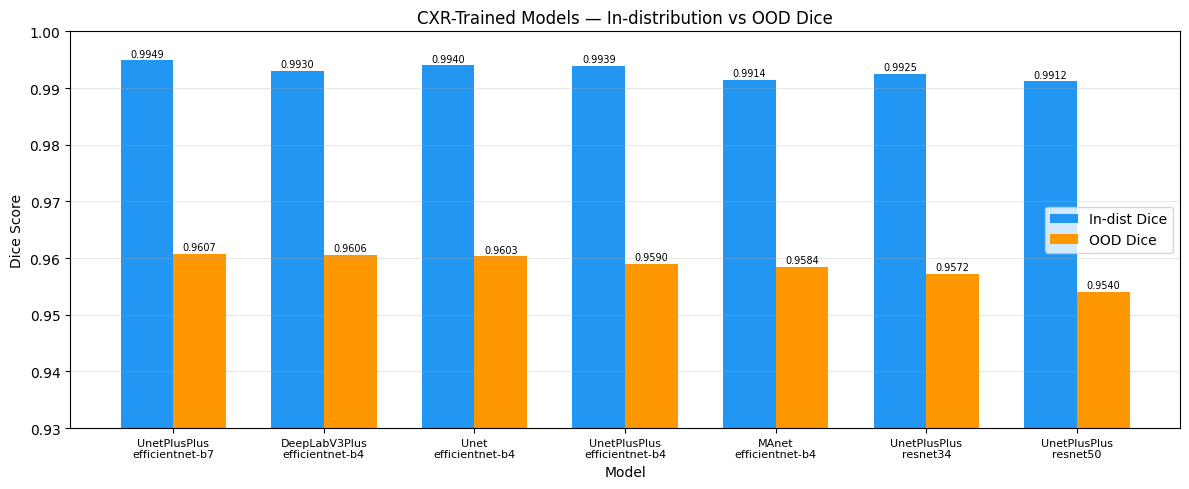

Saved fig1_cxr_indist_vs_ood.png


In [37]:
fig, ax = plt.subplots(figsize=(12, 5))

x       = np.arange(len(cxr_df))
width   = 0.35
labels  = [f"{r.arch}\n{r.encoder}" for _, r in cxr_df.iterrows()]

bars1 = ax.bar(x - width/2, cxr_df["indist_dice"], width, label="In-dist Dice", color="#2196F3")
bars2 = ax.bar(x + width/2, cxr_df["ood_dice"],    width, label="OOD Dice",     color="#FF9800")

ax.set_xlabel("Model")
ax.set_ylabel("Dice Score")
ax.set_title("CXR-Trained Models — In-distribution vs OOD Dice")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0.93, 1.00)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(DRIVE_DIR / "fig1_cxr_indist_vs_ood.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig1_cxr_indist_vs_ood.png")

## 8. Figure 2 — In-dist vs OOD Dice (COVIDQU-trained)

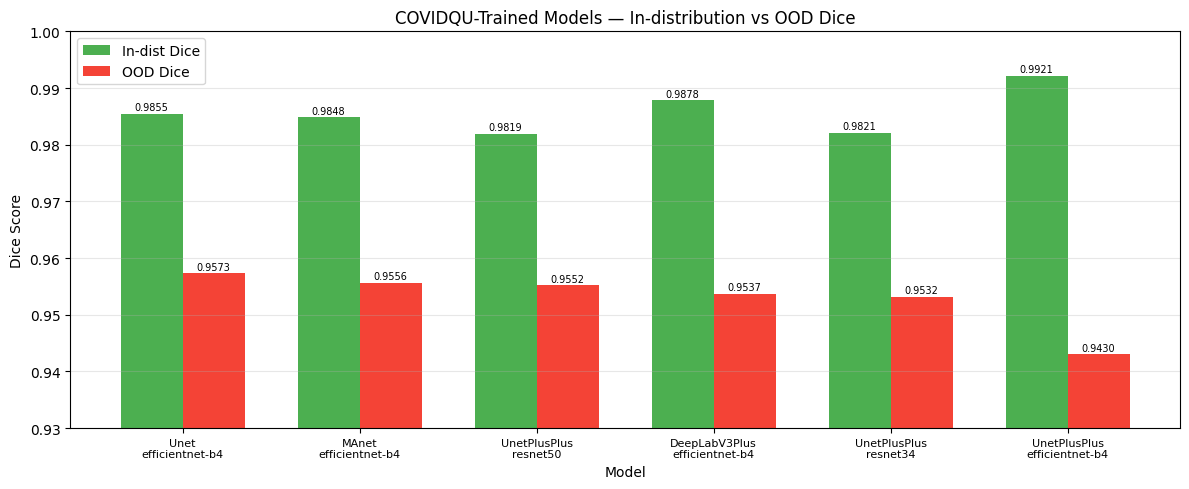

Saved fig2_covidqu_indist_vs_ood.png


In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

x       = np.arange(len(cov_df))
labels  = [f"{r.arch}\n{r.encoder}" for _, r in cov_df.iterrows()]

bars1 = ax.bar(x - width/2, cov_df["indist_dice"], width, label="In-dist Dice", color="#4CAF50")
bars2 = ax.bar(x + width/2, cov_df["ood_dice"],    width, label="OOD Dice",     color="#F44336")

ax.set_xlabel("Model")
ax.set_ylabel("Dice Score")
ax.set_title("COVIDQU-Trained Models — In-distribution vs OOD Dice")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0.93, 1.00)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(DRIVE_DIR / "fig2_covidqu_indist_vs_ood.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig2_covidqu_indist_vs_ood.png")

## 9. Figure 3 — OOD Dice: CXR-trained vs COVIDQU-trained (same arch/encoder)

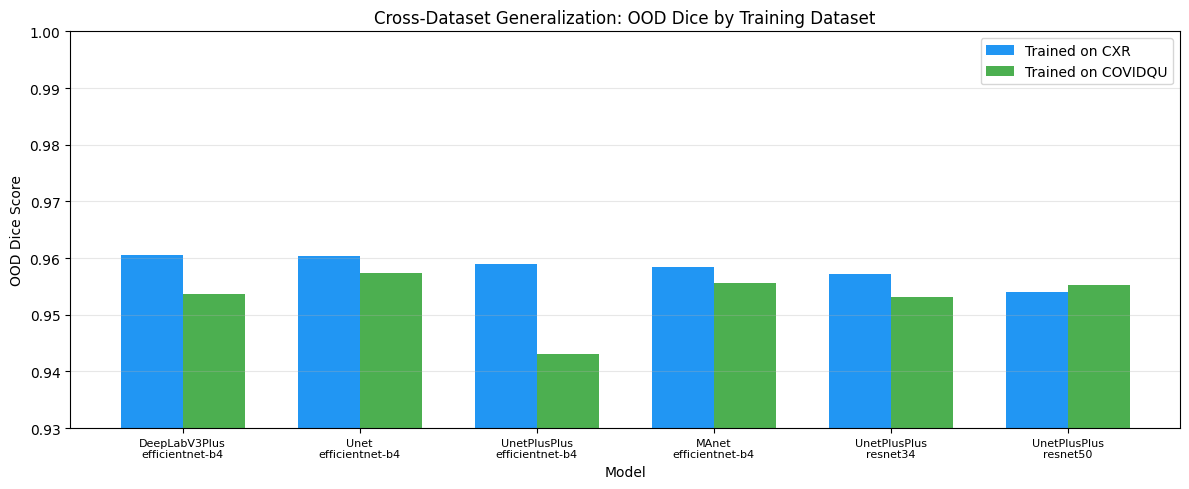

Saved fig3_ood_cxr_vs_covidqu.png


In [39]:
cxr_sub = df[df["train_dataset"] == "CXR"][["arch", "encoder", "ood_dice"]].rename(
    columns={"ood_dice": "ood_dice_cxr"})
cov_sub = df[df["train_dataset"] == "COVIDQU"][["arch", "encoder", "ood_dice"]].rename(
    columns={"ood_dice": "ood_dice_covidqu"})

merged = pd.merge(cxr_sub, cov_sub, on=["arch", "encoder"]).dropna()
merged["label"] = merged.apply(lambda r: f"{r.arch}\n{r.encoder}", axis=1)
merged = merged.sort_values("ood_dice_cxr", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(merged))

ax.bar(x - width/2, merged["ood_dice_cxr"],     width, label="Trained on CXR",     color="#2196F3")
ax.bar(x + width/2, merged["ood_dice_covidqu"],  width, label="Trained on COVIDQU", color="#4CAF50")

ax.set_xlabel("Model")
ax.set_ylabel("OOD Dice Score")
ax.set_title("Cross-Dataset Generalization: OOD Dice by Training Dataset")
ax.set_xticks(x)
ax.set_xticklabels(merged["label"], fontsize=8)
ax.set_ylim(0.93, 1.00)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE_DIR / "fig3_ood_cxr_vs_covidqu.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig3_ood_cxr_vs_covidqu.png")

## 10. Figure 4 — Generalization Gap (In-dist - OOD Dice)

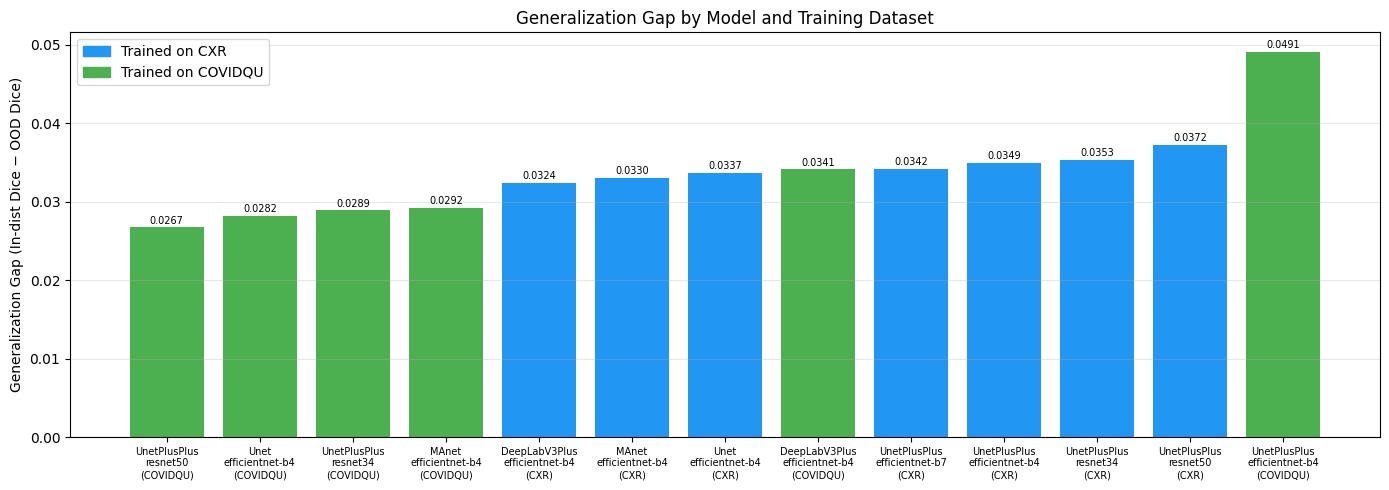

Saved fig4_generalization_gap.png


In [40]:
df["gap"] = df["indist_dice"] - df["ood_dice"]
gap_df    = df.sort_values("gap")

colors = ["#2196F3" if t == "CXR" else "#4CAF50" for t in gap_df["train_dataset"]]
labels = [f"{r.arch}\n{r.encoder}\n({r.train_dataset})" for _, r in gap_df.iterrows()]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(gap_df)), gap_df["gap"], color=colors)
ax.set_xticks(range(len(gap_df)))
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("Generalization Gap (In-dist Dice − OOD Dice)")
ax.set_title("Generalization Gap by Model and Training Dataset")
ax.grid(axis="y", alpha=0.3)

blue_patch  = mpatches.Patch(color="#2196F3", label="Trained on CXR")
green_patch = mpatches.Patch(color="#4CAF50", label="Trained on COVIDQU")
ax.legend(handles=[blue_patch, green_patch])

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(DRIVE_DIR / "fig4_generalization_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig4_generalization_gap.png")

## 12. Best Model Summary

In [41]:
print("\n" + "="*60)
print("BEST MODEL OVERALL")
print("="*60)
best_ood = df.loc[df["ood_dice"].idxmax()]
print(f"  By OOD Dice    : {best_ood.arch} + {best_ood.encoder} trained on {best_ood.train_dataset}")
print(f"    OOD Dice     : {best_ood.ood_dice:.4f}")
print(f"    InDist Dice  : {best_ood.indist_dice:.4f}")

best_indist = df.loc[df["indist_dice"].idxmax()]
print(f"\n  By InDist Dice : {best_indist.arch} + {best_indist.encoder} trained on {best_indist.train_dataset}")
print(f"    InDist Dice  : {best_indist.indist_dice:.4f}")
print(f"    OOD Dice     : {best_indist.ood_dice:.4f}")

smallest_gap = df.loc[df["gap"].idxmin()]
print(f"\n  Smallest Gap   : {smallest_gap.arch} + {smallest_gap.encoder} trained on {smallest_gap.train_dataset}")
print(f"    Gap          : {smallest_gap.gap:.4f}")
print(f"    InDist Dice  : {smallest_gap.indist_dice:.4f}")
print(f"    OOD Dice     : {smallest_gap.ood_dice:.4f}")


BEST MODEL OVERALL
  By OOD Dice    : UnetPlusPlus + efficientnet-b7 trained on CXR
    OOD Dice     : 0.9607
    InDist Dice  : 0.9949

  By InDist Dice : UnetPlusPlus + efficientnet-b7 trained on CXR
    InDist Dice  : 0.9949
    OOD Dice     : 0.9607

  Smallest Gap   : UnetPlusPlus + resnet50 trained on COVIDQU
    Gap          : 0.0267
    InDist Dice  : 0.9819
    OOD Dice     : 0.9552


## 13. Save Full Results CSV

In [42]:
csv_path = DRIVE_DIR / "all_results.csv"
df.to_csv(csv_path, index=False)
print(f"Full results saved → {csv_path}")
print(df[cols].sort_values(["train_dataset", "ood_dice"], ascending=[True, False]).to_string(index=False))

Full results saved → /content/drive/MyDrive/LungSeg_UNetPP/all_results.csv
         arch         encoder train_dataset  epochs_trained  best_val_dice  indist_dice  indist_iou  ood_dice  ood_iou
         Unet efficientnet-b4       COVIDQU              50         0.9853       0.9855      0.9714    0.9573   0.9182
        MAnet efficientnet-b4       COVIDQU              50         0.9847       0.9848      0.9701    0.9556   0.9150
 UnetPlusPlus        resnet50       COVIDQU              51         0.9817       0.9819      0.9645    0.9552   0.9143
DeepLabV3Plus efficientnet-b4       COVIDQU              50         0.9877       0.9878      0.9759    0.9537   0.9115
 UnetPlusPlus        resnet34       COVIDQU              50         0.9819       0.9821      0.9649    0.9532   0.9106
 UnetPlusPlus efficientnet-b4       COVIDQU              50         0.9921       0.9921      0.9843    0.9430   0.8923
 UnetPlusPlus efficientnet-b7           CXR              50         0.9947       0.9949     

In [43]:
print("All subfolders in LungSeg_UNetPP:")
for item in sorted(DRIVE_DIR.iterdir()):
    if item.is_dir():
        print(f"  {item.name}")
    elif item.suffix == ".json":
        print(f"  {item.name}  ← root level JSON")

All subfolders in LungSeg_UNetPP:
  UNetPP_efficientnet-b4_history.json  ← root level JSON
  UNetPP_efficientnet-b4_summary.json  ← root level JSON
  deeplabv3plus_efficientnetb4_COVIDQU
  deeplabv3plus_efficientnetb4_CXR
  manet_efficientnetb4_COVIDQU
  manet_efficientnetb4_CXR
  unet_efficientnetb4_COVIDQU
  unet_efficientnetb4_CXR
  unetpp_efficientnetb4_COVIDQU
  unetpp_efficientnetb4_COVIDQU_history.json  ← root level JSON
  unetpp_efficientnetb4_COVIDQU_summary.json  ← root level JSON
  unetpp_efficientnetb7_CXR_history.json  ← root level JSON
  unetpp_efficientnetb7_CXR_summary.json  ← root level JSON
  unetpp_resnet34_COVIDQU
  unetpp_resnet34_CXR
  unetpp_resnet50_COVIDQU_history.json  ← root level JSON
  unetpp_resnet50_COVIDQU_summary.json  ← root level JSON
  unetpp_resnet50_CXR
